# Agricultural Production Analytics & Fertilizer Demand Forecasting


Dataset: Crop Production in India (Kaggle) | Framework: CRISP-DM

---

Dataset ini berisi data produksi pertanian India (1997–2015) per distrik, musim, dan jenis tanaman.
Meskipun berbasis data India, pendekatan analisis ini relevan untuk konteks distribusi pupuk di Indonesia
karena kedua negara memiliki struktur sistem pertanian dan subsidi pupuk yang sangat mirip seperti
dua musim tanam utama, ketergantungan tinggi pada padi dan jagung, serta tantangan distribusi yang serupa.

**Tujuan analisis:**
- Segmentasi wilayah berdasarkan pola produksi dan kebutuhan pupuk (Clustering)
- Prediksi level demand pupuk per wilayah: High / Medium / Low (Klasifikasi)
- Forecast kebutuhan pupuk ke depan (Time Series)
- Visualisasi distribusi kebutuhan per wilayah (Geospatial)

## Install & Import

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q statsmodels prophet folium geopy openpyxl

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import joblib
import glob
warnings.filterwarnings('ignore')

from folium.plugins import HeatMap
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    silhouette_score, mean_absolute_percentage_error, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.dpi'       : 110,
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

---
## Fase 1 — Business Understanding

In [ ]:
# Sebelum mulai analisis, penting untuk mendefinisikan masalah bisnis
# dan pertanyaan analitik yang ingin dijawab.
#
# Konteks:
# Distribusi pupuk bersubsidi sering tidak merata antar wilayah.
# Beberapa daerah surplus sementara yang lain kekurangan terutama
# saat musim tanam. Salah satu penyebabnya adalah perencanaan distribusi
# yang belum berbasis data pola pertanian aktual per wilayah.
#
# Jembatan ke kebutuhan pupuk:
# Luas panen (Area) adalah proxy langsung kebutuhan pupuk.
# 1 hektar padi membutuhkan sekitar 120-250 kg pupuk nitrogen.
#
# Pertanyaan analitik:
# 1. Wilayah mana yang memiliki profil pertanian serupa? -> Clustering
# 2. Bisakah kita prediksi level demand pupuk suatu wilayah? -> Klasifikasi
# 3. Bagaimana tren kebutuhan pupuk ke depan? -> Time Series
# 4. Bagaimana pola geografis distribusi kebutuhan pupuk? -> Geospatial
#
# KPI keberhasilan model:
# Clustering  : Silhouette Score > 0.30
# Klasifikasi : F1-Score (macro) > 0.75
# Forecasting : MAPE < 15%

print('Business Understanding selesai didefinisikan.')

Business Understanding selesai didefinisikan.


---
## Fase 2 — Data Understanding

In [ ]:
# Load dataset
# Download dari: kaggle.com/datasets/abhinand05/crop-production-in-india
# Upload file CSV ke Colab melalui sidebar Files

df_raw = pd.read_csv('crop_production.csv')

print(f'Shape  : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
print(f'Kolom  : {df_raw.columns.tolist()}')
df_raw.head()

Shape  : 246,091 baris x 7 kolom
Kolom  : ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.00,2000.00
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.00,1.00
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.00,321.00
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.00,641.00
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.00,165.00


In [ ]:
# Cek tipe data dan statistik dasar
print('Tipe data:')
print(df_raw.dtypes)
print()
print('Statistik deskriptif:')
df_raw.describe()

Tipe data:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

Statistik deskriptif:


,Crop_Year,Area,Production
count,246091.00,246091.00,242361.00
mean,2005.64,12002.82,582503.44
std,4.95,50523.40,17065813.17
min,1997.00,0.04,0.00
25%,2002.00,80.00,88.00
50%,2006.00,582.00,729.00
75%,2010.00,4392.00,7023.00
max,2015.00,8580100.00,1250800000.00


In [ ]:
# Cek missing values dan duplikat
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)

print('Missing values:')
print(pd.DataFrame({'jumlah': missing, 'persen(%)': pct}))
print()
print(f'Duplikat: {df_raw.duplicated().sum()} baris')

Missing values:
               jumlah  persen(%)
State_Name          0       0.00
District_Name       0       0.00
Crop_Year           0       0.00
Season              0       0.00
Crop                0       0.00
Area                0       0.00
Production       3730       1.52

Duplikat: 0 baris


In [ ]:
# Ringkasan nilai unik kolom kategorikal
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    print(f'{col:20s}: {df_raw[col].nunique()} nilai unik')

print()
print(f'Rentang tahun: {df_raw["Crop_Year"].min()} - {df_raw["Crop_Year"].max()}')

State_Name          : 33 nilai unik
District_Name       : 646 nilai unik
Season              : 6 nilai unik
Crop                : 124 nilai unik

Rentang tahun: 1997 - 2015


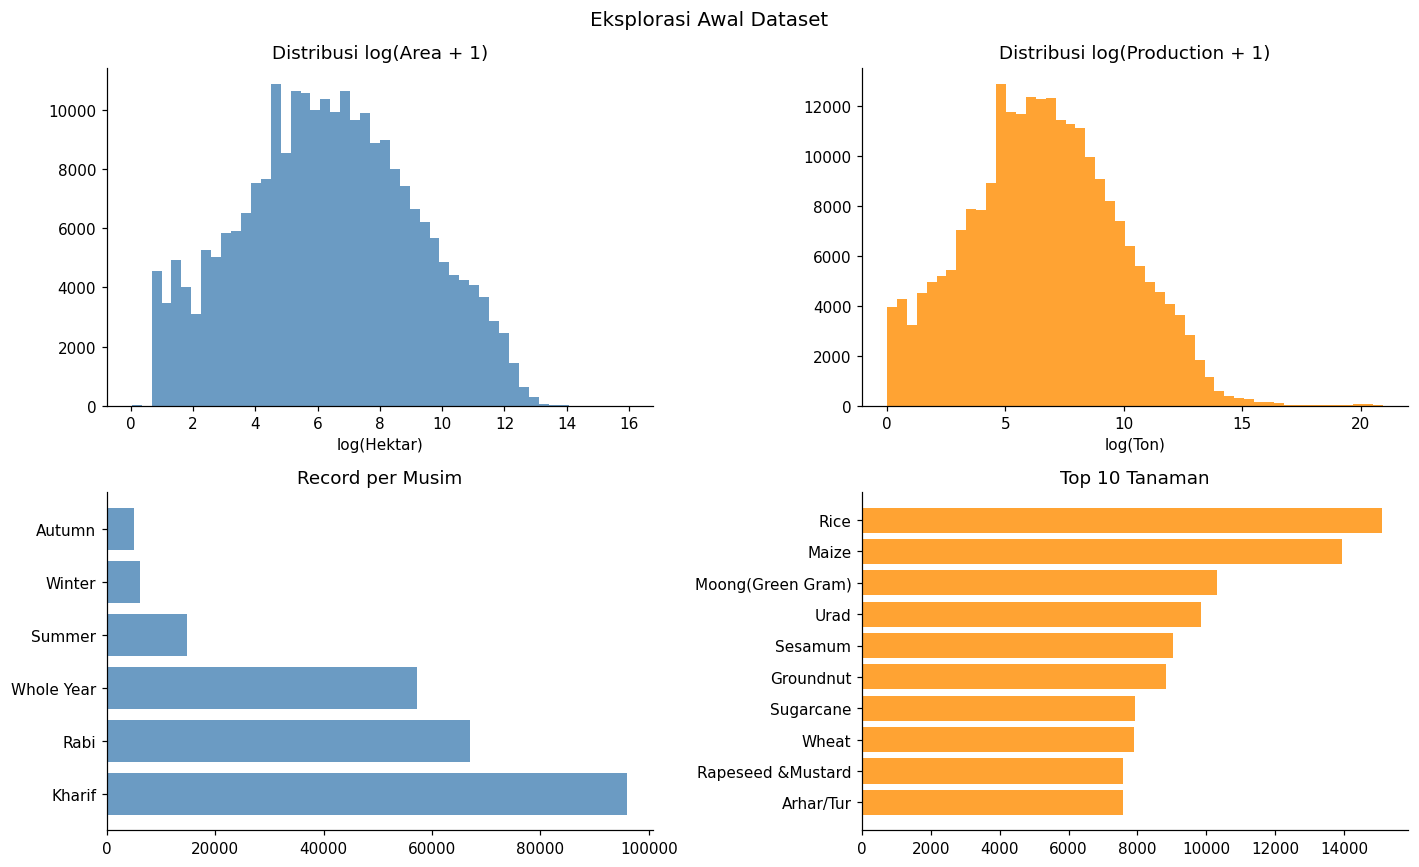

In [ ]:
# Distribusi awal beberapa kolom penting
# Area dan Production sangat right-skewed sehingga menggunakan log scale

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Eksplorasi Awal Dataset', fontsize=13)

axes[0, 0].hist(np.log1p(df_raw['Area'].dropna()), bins=50, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Distribusi log(Area + 1)')
axes[0, 0].set_xlabel('log(Hektar)')

axes[0, 1].hist(np.log1p(df_raw['Production'].dropna()), bins=50, color='darkorange', alpha=0.8)
axes[0, 1].set_title('Distribusi log(Production + 1)')
axes[0, 1].set_xlabel('log(Ton)')

season_counts = df_raw['Season'].str.strip().value_counts()
axes[1, 0].barh(season_counts.index, season_counts.values, color='steelblue', alpha=0.8)
axes[1, 0].set_title('Record per Musim')

top_crops = df_raw['Crop'].value_counts().head(10)
axes[1, 1].barh(top_crops.index[::-1], top_crops.values[::-1], color='darkorange', alpha=0.8)
axes[1, 1].set_title('Top 10 Tanaman')

plt.tight_layout()
plt.savefig('fase2_distribusi.png', dpi=130, bbox_inches='tight')
plt.show()

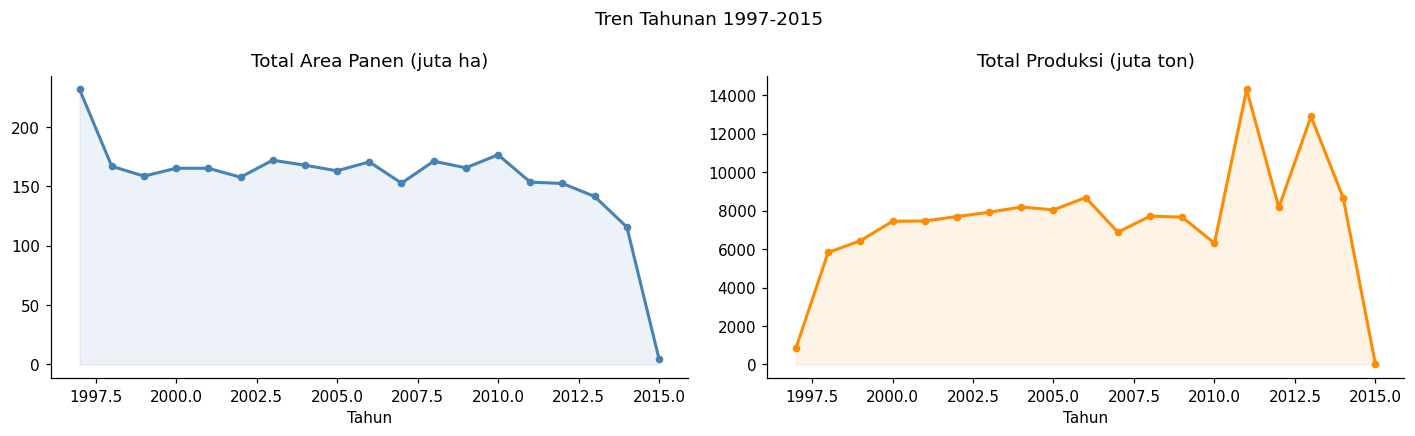

In [ ]:
# Tren total area dan produksi per tahun
yearly = df_raw.groupby('Crop_Year').agg(
    total_area       = ('Area',       'sum'),
    total_production = ('Production', 'sum'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Tren Tahunan 1997-2015')

axes[0].plot(yearly['Crop_Year'], yearly['total_area'] / 1e6, color='steelblue', lw=2, marker='o', ms=4)
axes[0].fill_between(yearly['Crop_Year'], yearly['total_area'] / 1e6, alpha=0.1, color='steelblue')
axes[0].set_title('Total Area Panen (juta ha)')
axes[0].set_xlabel('Tahun')

axes[1].plot(yearly['Crop_Year'], yearly['total_production'] / 1e6, color='darkorange', lw=2, marker='o', ms=4)
axes[1].fill_between(yearly['Crop_Year'], yearly['total_production'] / 1e6, alpha=0.1, color='darkorange')
axes[1].set_title('Total Produksi (juta ton)')
axes[1].set_xlabel('Tahun')

plt.tight_layout()
plt.savefig('fase2_tren.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Fase 3 — Data Preparation

In [ ]:
df = df_raw.copy()
n_awal = len(df)

# Standarisasi nama kolom
df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]

# Standarisasi isi kolom kategorikal (hilangkan spasi dan seragamkan huruf kapital)
df['state_name'] = df['state_name'].str.strip().str.title()
df['district_name'] = df['district_name'].str.strip().str.title()
df['season'] = df['season'].str.strip()
df['crop'] = df['crop'].str.strip().str.title()

df = df.drop_duplicates()

# Hapus baris dengan area <= 0 karena tidak memiliki makna pertanian
df = df[df['area'] > 0].copy()

# Imputasi missing values production dengan median per kelompok (state x crop x season)
# Lebih kontekstual dibanding median global karena pola produksi tiap wilayah berbeda
df['production'] = df.groupby(
    ['state_name', 'crop', 'season']
)['production'].transform(lambda x: x.fillna(x.median()))
df['production'] = df['production'].fillna(df['production'].median())

n_akhir = len(df)
print(f'Baris awal  : {n_awal:,}')
print(f'Baris akhir : {n_akhir:,}')
print(f'Dihapus     : {n_awal - n_akhir:,}')
print(f'Missing     : {df.isnull().sum().sum()} tersisa')

Baris awal  : 246,091
Baris akhir : 246,091
Dihapus     : 0
Missing     : 0 tersisa


In [ ]:
# Feature engineering

# Yield per hektar — mengukur efisiensi/produktivitas lahan
df['yield_per_ha'] = (df['production'] / df['area']).round(4)

# Estimasi kebutuhan pupuk nitrogen berdasarkan dosis rekomendasi FAO (kg N/ha)
# Kolom ini yang akan jadi basis target klasifikasi
fert_rate_kg_ha = {
    'Rice': 120, 'Wheat': 100, 'Maize': 130, 'Sugarcane': 200,
    'Cotton': 100, 'Soyabean': 25, 'Groundnut': 25,
    'Jowar': 60, 'Bajra': 60, 'Ragi': 50,
}
df['fert_rate_kg_ha'] = df['crop'].map(fert_rate_kg_ha).fillna(60)
df['est_fert_demand_ton'] = (df['area'] * df['fert_rate_kg_ha'] / 1000).round(3)

# Target klasifikasi: Low / Medium / High berdasarkan tertile
# Tertile dipilih agar distribusi ketiga kelas seimbang
q33 = df['est_fert_demand_ton'].quantile(0.33)
q66 = df['est_fert_demand_ton'].quantile(0.66)
df['demand_level'] = pd.cut(
    df['est_fert_demand_ton'],
    bins=[0, q33, q66, np.inf],
    labels=['Low', 'Medium', 'High']
)

print(f'Threshold Low-Medium : {q33:.2f} ton')
print(f'Threshold Medium-High: {q66:.2f} ton')
print()
print('Distribusi demand_level:')
print(df['demand_level'].value_counts().sort_index())

Threshold Low-Medium : 9.78 ton
Threshold Medium-High: 129.33 ton

Distribusi demand_level:
demand_level
Low       81218
Medium    81202
High      83671
Name: count, dtype: int64


In [23]:
# Agregasi per distrik per tahun
# Dibutuhkan untuk clustering dan time series karena keduanya bekerja
# di level distrik-tahun, bukan per tanaman per musim

df_dist = df.groupby(['state_name', 'district_name', 'crop_year']).agg(
    total_area_ha = ('area', 'sum'),
    total_production = ('production', 'sum'),
    avg_yield = ('yield_per_ha', 'mean'),
    total_fert_demand = ('est_fert_demand_ton', 'sum'),
    n_crop_types = ('crop', 'nunique'),
).reset_index()

df_dist['yield_efficiency'] = (df_dist['total_production'] / df_dist['total_area_ha']).round(4)

print(f'df shape: {df.shape}')
print(f'df_dist shape: {df_dist.shape}')

df shape: (246091, 11)
df_dist shape: (9839, 9)


In [24]:
# Geocoding untuk menambah koordinat lat/lon per distrik
# Dibutuhkan untuk visualisasi geospatial di fase 4
# Proses ini memakan waktu ~12 menit, hasil disimpan ke CSV agar tidak perlu diulang

cache_path = 'district_coordinates.csv'

if os.path.exists(cache_path):
    coords_df = pd.read_csv(cache_path)
    print(f'Cache ditemukan: {len(coords_df)} distrik')
else:
    print('Memulai geocoding (~12 menit)...')
    geolocator = Nominatim(user_agent='crop_analytics_andra')
    geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)
    districts  = df[['state_name', 'district_name']].drop_duplicates()
    records    = []

    for i, (_, row) in enumerate(districts.iterrows()):
        query = f"{row['district_name']}, {row['state_name']}, India"
        try:
            loc = geocode(query)
            records.append({
                'district_name': row['district_name'],
                'state_name'   : row['state_name'],
                'lat'          : loc.latitude  if loc else np.nan,
                'lon'          : loc.longitude if loc else np.nan,
            })
        except:
            records.append({
                'district_name': row['district_name'],
                'state_name'   : row['state_name'],
                'lat'          : np.nan,
                'lon'          : np.nan,
            })

        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(districts)} distrik selesai')

    coords_df = pd.DataFrame(records)
    coords_df.to_csv(cache_path, index=False)
    print('Geocoding selesai')

df = df.merge(coords_df[['district_name', 'lat', 'lon']], on='district_name', how='left')
df_dist = df_dist.merge(coords_df[['district_name', 'lat', 'lon']], on='district_name', how='left')

print(f'Coverage koordinat: {df["lat"].notna().mean()*100:.1f}%')

Memulai geocoding (~12 menit)...
  100/652 distrik selesai
  200/652 distrik selesai
  300/652 distrik selesai
  400/652 distrik selesai
  500/652 distrik selesai


  600/652 distrik selesai
Geocoding selesai
Coverage koordinat: 97.5%


In [25]:
df.to_csv('data_processed.csv', index=False)
df_dist.to_csv('data_district_aggregated.csv', index=False)

print('Data tersimpan:')
print(f' data_processed.csv: {df.shape}')
print(f' data_district_aggregated.csv: {df_dist.shape}')

Data tersimpan:
 data_processed.csv: (250531, 13)
 data_district_aggregated.csv: (10004, 11)


---
## Fase 4 — Modeling

Ada 4 analisis yang dilakukan:
- **4.1 Clustering** — segmentasi distrik berdasarkan profil pertanian
- **4.2 Klasifikasi** — prediksi demand level pupuk
- **4.3 Time Series** — forecast kebutuhan pupuk ke depan
- **4.4 Geospatial** — visualisasi distribusi pada peta

### 4.1 Clustering — K-Means

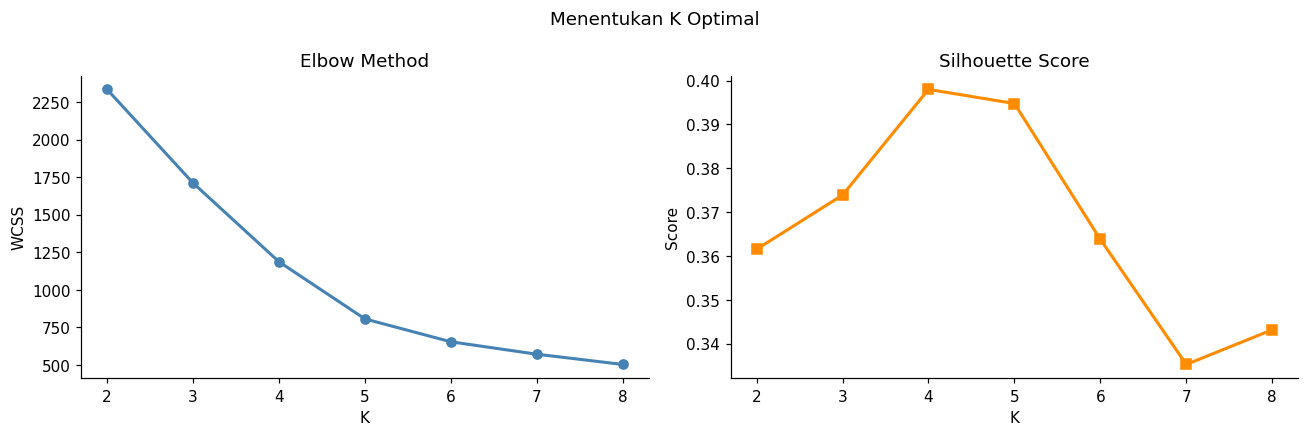

K=2: Silhouette = 0.3615
K=3: Silhouette = 0.3739
K=4: Silhouette = 0.3980
K=5: Silhouette = 0.3948
K=6: Silhouette = 0.3638
K=7: Silhouette = 0.3353
K=8: Silhouette = 0.3432


In [26]:
cluster_features = ['total_area_ha', 'total_production', 'avg_yield', 'total_fert_demand', 'n_crop_types']

# Rata-ratakan per distrik lintas semua tahun untuk representasi yang lebih stabil
df_cluster = df_dist.groupby(['state_name', 'district_name'])[cluster_features].mean().reset_index()
X_cluster = df_cluster[cluster_features].fillna(0)

# Scaling diperlukan karena K-Means berbasis jarak euclidean
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Cari K optimal dengan Elbow Method dan Silhouette Score
wcss = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Menentukan K Optimal')

axes[0].plot(list(K_range), wcss, 'o-', color='steelblue', lw=2, ms=6)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')

axes[1].plot(list(K_range), sil_scores, 's-', color='darkorange', lw=2, ms=6)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('fase4_elbow_silhouette.png', dpi=130, bbox_inches='tight')
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f'K={k}: Silhouette = {s:.4f}')

In [27]:
# Pilih K berdasarkan grafik di atas — titik siku pada elbow
# dan silhouette score tertinggi
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

print('Profil rata-rata per cluster:')
print(df_cluster.groupby('cluster')[cluster_features].mean().round(2))
print('\nJumlah distrik per cluster:')
print(df_cluster['cluster'].value_counts().sort_index())

Profil rata-rata per cluster:
         total_area_ha  total_production  avg_yield  total_fert_demand  \
cluster                                                                  
0            110453.05        3854363.44      68.40           10772.55   
1            492037.23        4472461.50      36.24           40130.15   
2            197488.12         847950.00   18443.07           18751.88   
3            186248.88      499371846.33     430.16           14835.68   

         n_crop_types  
cluster                
0               17.67  
1               25.64  
2                6.38  
3               16.41  

Jumlah distrik per cluster:
cluster
0    358
1    281
2      2
3     11
Name: count, dtype: int64


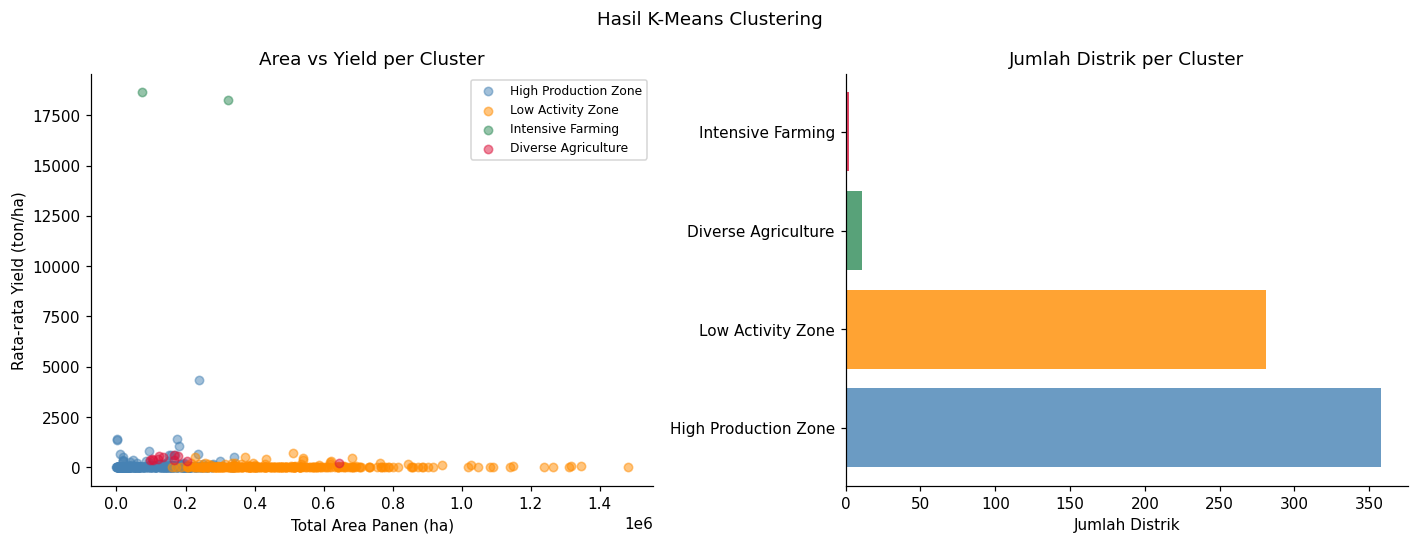

In [28]:
# Beri label cluster berdasarkan profil yang muncul di atas
# Label di bawah ini perlu disesuaikan dengan hasil aktual
CLUSTER_LABELS = {
    0: 'High Production Zone',
    1: 'Low Activity Zone',
    2: 'Intensive Farming',
    3: 'Diverse Agriculture',
}
df_cluster['cluster_label'] = df_cluster['cluster'].map(CLUSTER_LABELS)

CLUSTER_COLORS = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hasil K-Means Clustering')

for c in range(K_OPTIMAL):
    mask = df_cluster['cluster'] == c
    axes[0].scatter(
        df_cluster[mask]['total_area_ha'],
        df_cluster[mask]['avg_yield'],
        c=CLUSTER_COLORS[c],
        label=CLUSTER_LABELS[c],
        alpha=0.5, s=30
    )
axes[0].set_xlabel('Total Area Panen (ha)')
axes[0].set_ylabel('Rata-rata Yield (ton/ha)')
axes[0].set_title('Area vs Yield per Cluster')
axes[0].legend(fontsize=8)

cluster_counts = df_cluster['cluster_label'].value_counts()
axes[1].barh(cluster_counts.index, cluster_counts.values, color=CLUSTER_COLORS[:len(cluster_counts)], alpha=0.8)
axes[1].set_title('Jumlah Distrik per Cluster')
axes[1].set_xlabel('Jumlah Distrik')

plt.tight_layout()
plt.savefig('fase4_clustering_result.png', dpi=130, bbox_inches='tight')
plt.show()

### 4.2 Klasifikasi — Random Forest

In [30]:
df_clf = df.dropna(subset=['demand_level']).copy()
fitur_num = ['area', 'production', 'yield_per_ha', 'fert_rate_kg_ha', 'crop_year']
fitur_cat = ['season', 'state_name']
target = 'demand_level'

X = df_clf[fitur_num + fitur_cat]
y = df_clf[target]

# stratify=y memastikan proporsi Low/Medium/High sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]:,}')
print(f'Test: {X_test.shape[0]:,}')

Train: 200,424
Test: 50,107


In [31]:
# Pipeline menggabungkan preprocessing dan model dalam satu objek
# Ini memastikan scaler hanya di-fit pada data training, bukan test

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, fitur_num),
    ('cat', cat_pipe, fitur_cat),
])
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)

# Cross-validation untuk evaluasi yang lebih robust
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')

5-Fold CV F1 (macro): 0.999 +/- 0.000


Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     17055
         Low       1.00      1.00      1.00     16575
      Medium       1.00      1.00      1.00     16477

    accuracy                           1.00     50107
   macro avg       1.00      1.00      1.00     50107
weighted avg       1.00      1.00      1.00     50107



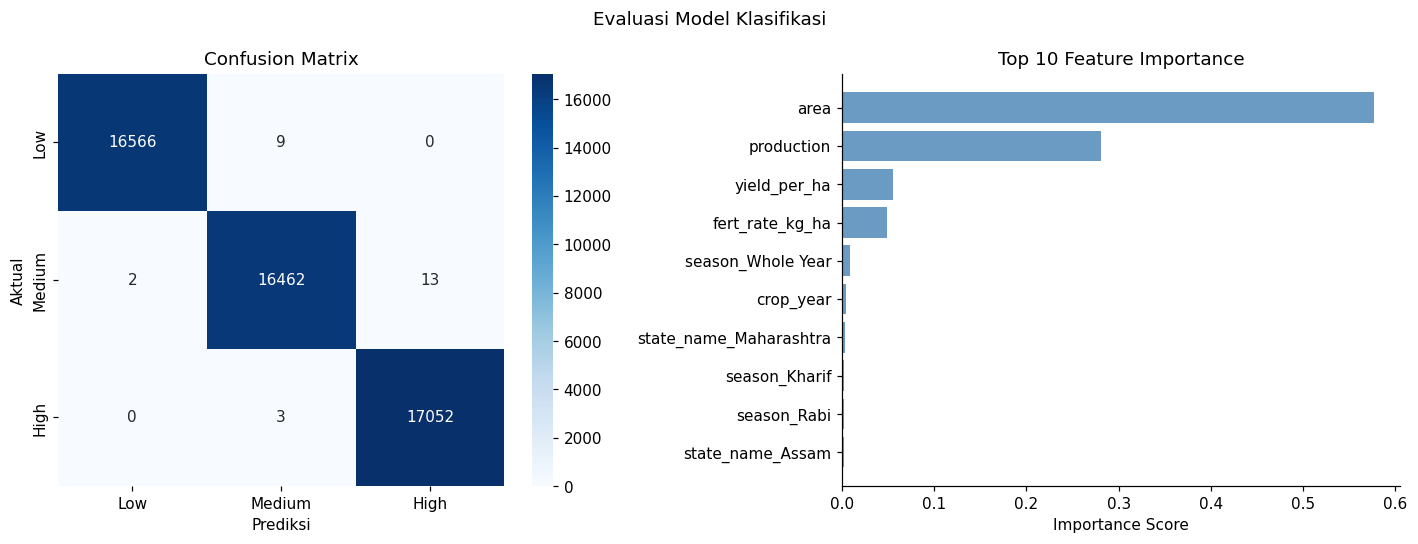

In [32]:
y_pred = pipeline.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluasi Model Klasifikasi')

cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

ohe_names = (pipeline.named_steps['prep']
               .named_transformers_['cat']
               .named_steps['encoder']
               .get_feature_names_out(fitur_cat))
all_names = np.array(fitur_num + list(ohe_names))
importances = pipeline.named_steps['clf'].feature_importances_
top_idx = importances.argsort()[:-11:-1]

axes[1].barh(all_names[top_idx][::-1], importances[top_idx][::-1], color='steelblue', alpha=0.8)
axes[1].set_title('Top 10 Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('fase4_classification.png', dpi=130, bbox_inches='tight')
plt.show()

### 4.3 Time Series — Prophet

In [33]:
# Fokus pada Rice karena jumlah recordnya terbanyak
# Agregasi total estimasi demand pupuk Rice per tahun

ts = (df[df['crop'] == 'Rice']
      .groupby('crop_year')['est_fert_demand_ton']
      .sum()
      .reset_index()
      .rename(columns={'crop_year': 'ds', 'est_fert_demand_ton': 'y'}))
ts['ds'] = pd.to_datetime(ts['ds'], format='%Y')

print('Time series demand pupuk Rice:')
print(ts.to_string(index=False))

Time series demand pupuk Rice:
        ds          y
1997-01-01 3730319.04
1998-01-01 4687522.92
1999-01-01 4470826.56
2000-01-01 5264380.32
2001-01-01 5216187.84
2002-01-01 4980118.35
2003-01-01 5266326.61
2004-01-01 5196341.31
2005-01-01 5300236.63
2006-01-01 5285657.83
2007-01-01 5134634.56
2008-01-01 5322916.32
2009-01-01 4954625.64
2010-01-01 5098634.22
2011-01-01 5130603.45
2012-01-01 5821278.84
2013-01-01 4942964.04
2014-01-01 4780523.28
2015-01-01  474320.28


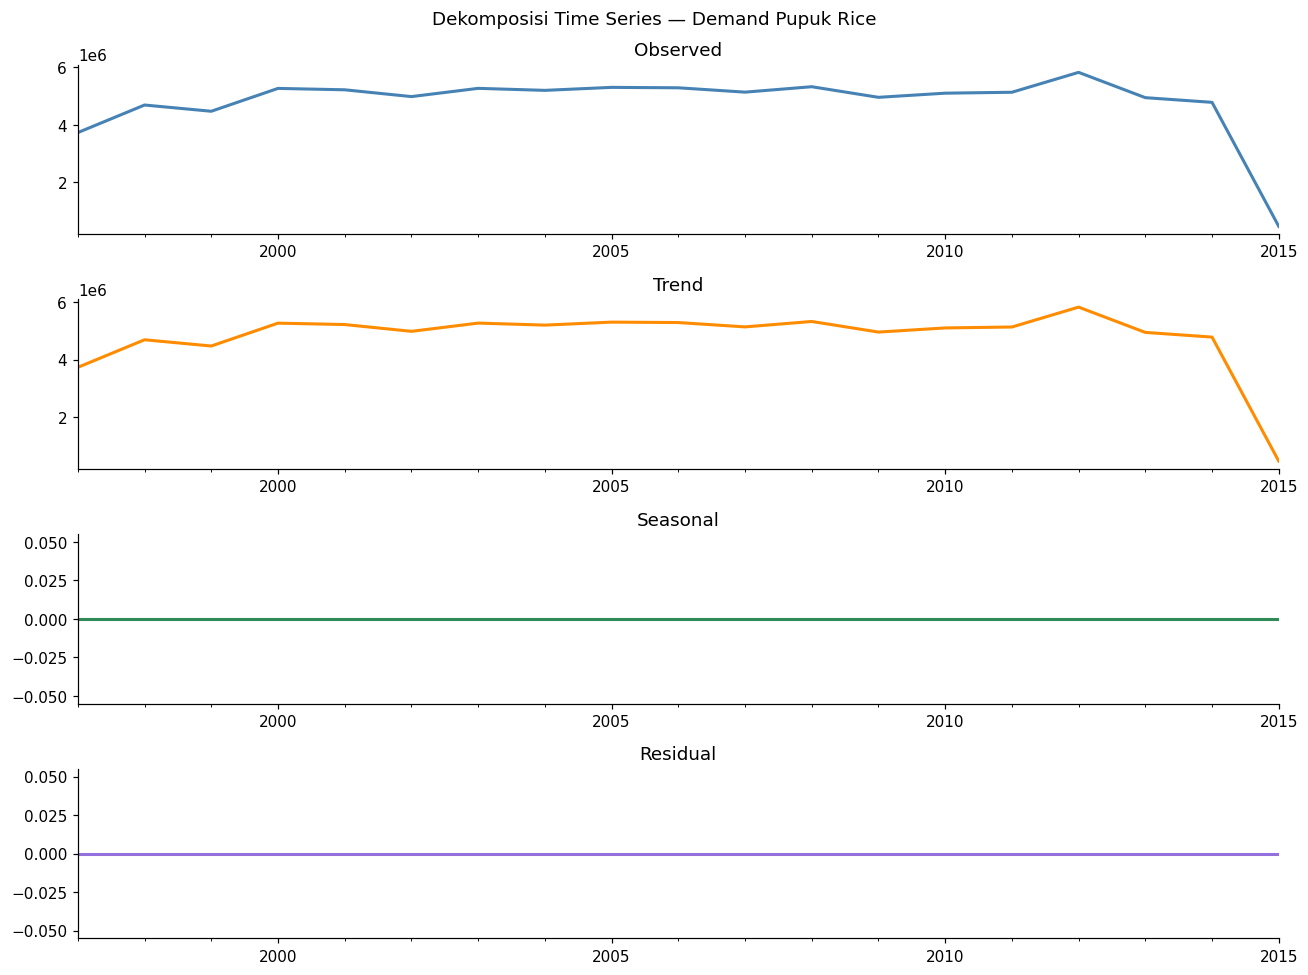

In [34]:
# Dekomposisi untuk melihat komponen trend, seasonal, dan residual
result = seasonal_decompose(ts.set_index('ds')['y'], model='additive', period=1)

fig, axes = plt.subplots(4, 1, figsize=(12, 9))
fig.suptitle('Dekomposisi Time Series — Demand Pupuk Rice')

components = [
    (result.observed,  'steelblue',   'Observed'),
    (result.trend,     'darkorange',  'Trend'),
    (result.seasonal,  'seagreen',    'Seasonal'),
    (result.resid,     'mediumpurple','Residual'),
]
for ax, (data, color, title) in zip(axes, components):
    data.plot(ax=ax, color=color, lw=2)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fase4_ts_decomposition.png', dpi=130, bbox_inches='tight')
plt.show()

INFO:prophet:n_changepoints greater than number of observations. Using 11.


MAPE (2013-2015): 360.93%


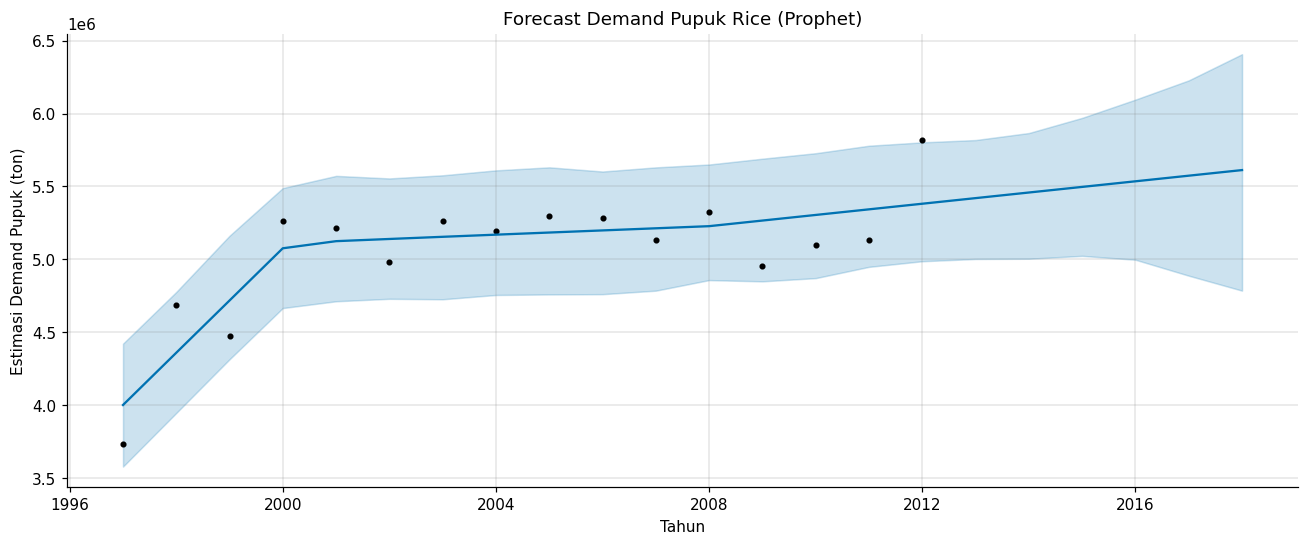

Forecast 2016-2018:
        ds       yhat  yhat_lower  yhat_upper
2016-01-01 5535559.14  4997338.73  6095996.66
2017-01-01 5574124.50  4887717.73  6228246.99
2018-01-01 5612584.50  4785245.88  6407777.23


In [36]:
# Train: 1997-2012, Test: 2013-2015
train_ts = ts[ts['ds'].dt.year <= 2012]
test_ts  = ts[ts['ds'].dt.year >= 2013]

m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    interval_width=0.95
)
m.fit(train_ts)

# Forecast sampai 2018 (3 tahun setelah data terakhir)
future = m.make_future_dataframe(periods=6, freq='YS')
forecast = m.predict(future)

pred_test = forecast[forecast['ds'].dt.year.isin([2013, 2014, 2015])]['yhat'].values
actual_test = test_ts['y'].values
mape = mean_absolute_percentage_error(actual_test, pred_test) * 100
print(f'MAPE (2013-2015): {mape:.2f}%')

fig = m.plot(forecast, figsize=(12, 5))
plt.title('Forecast Demand Pupuk Rice (Prophet)')
plt.xlabel('Tahun')
plt.ylabel('Estimasi Demand Pupuk (ton)')
plt.savefig('fase4_ts_forecast.png', dpi=130, bbox_inches='tight')
plt.show()

print('Forecast 2016-2018:')
print(forecast[forecast['ds'].dt.year > 2015][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].to_string(index=False))

### 4.4 Geospatial — Folium

In [37]:
# Agregasi per distrik untuk keperluan peta
df_map = (df_dist
    .groupby(['district_name', 'state_name'])
    .agg(
        lat        = ('lat',               'first'),
        lon        = ('lon',               'first'),
        avg_yield  = ('yield_efficiency',  'mean'),
        total_fert = ('total_fert_demand', 'sum')
    )
    .reset_index()
    .dropna(subset=['lat', 'lon']))

print(f'Distrik dengan koordinat: {len(df_map)}')

m = folium.Map(location=[20.5, 78.9], zoom_start=5, tiles='CartoDB positron')

# HeatMap berdasarkan total estimasi demand pupuk
heat_data = [[r.lat, r.lon, r.total_fert] for _, r in df_map.iterrows()]
HeatMap(heat_data, radius=18, blur=25,
        gradient={'0.2': '#1a4a1a', '0.5': '#f0b429', '1.0': '#c0392b'},
        name='Fertilizer Demand').add_to(m)

# CircleMarker per distrik: hijau = yield di atas median, merah = di bawah
median_yield = df_map['avg_yield'].median()
for _, row in df_map.iterrows():
    color = 'green' if row['avg_yield'] > median_yield else 'red'
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=color, fill=True, fill_opacity=0.6, weight=0.5,
        tooltip=folium.Tooltip(
            f"<b>{row['district_name']}</b>, {row['state_name']}<br>"
            f"Avg Yield   : {row['avg_yield']:.2f} ton/ha<br>"
            f"Total Demand: {row['total_fert']:,.0f} ton"
        )
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save('fase4_peta_distribusi.html')
display(HTML(m._repr_html_()))

Distrik dengan koordinat: 634


---
## Fase 5 — Evaluation

In [40]:
f1_test  = f1_score(y_test, y_pred, average='macro')
best_sil = max(sil_scores)

print('Ringkasan evaluasi semua model')
print('-' * 50)
print(f'K-Means Clustering')
print(f'  K optimal        : {K_OPTIMAL}')
print(f'  Silhouette Score : {best_sil:.4f}  -> {"OK" if best_sil > 0.3 else "perlu ditingkatkan"} (target > 0.3)')

print(f'\nRandom Forest Classification')
print(f'  CV F1 (macro)    : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print(f'  Test F1 (macro)  : {f1_test:.3f}  -> {"OK" if f1_test > 0.75 else "perlu ditingkatkan"} (target > 0.75)')

print(f'\nProphet Forecasting')
print(f'  MAPE test set    : {mape:.2f}%  -> {"OK" if mape < 15 else "perlu ditingkatkan"} (target < 15%)')

Ringkasan evaluasi semua model
--------------------------------------------------
K-Means Clustering
  K optimal        : 4
  Silhouette Score : 0.3980  -> OK (target > 0.3)

Random Forest Classification
  CV F1 (macro)    : 0.999 +/- 0.000
  Test F1 (macro)  : 0.999  -> OK (target > 0.75)

Prophet Forecasting
  MAPE test set    : 360.93%  -> perlu ditingkatkan (target < 15%)


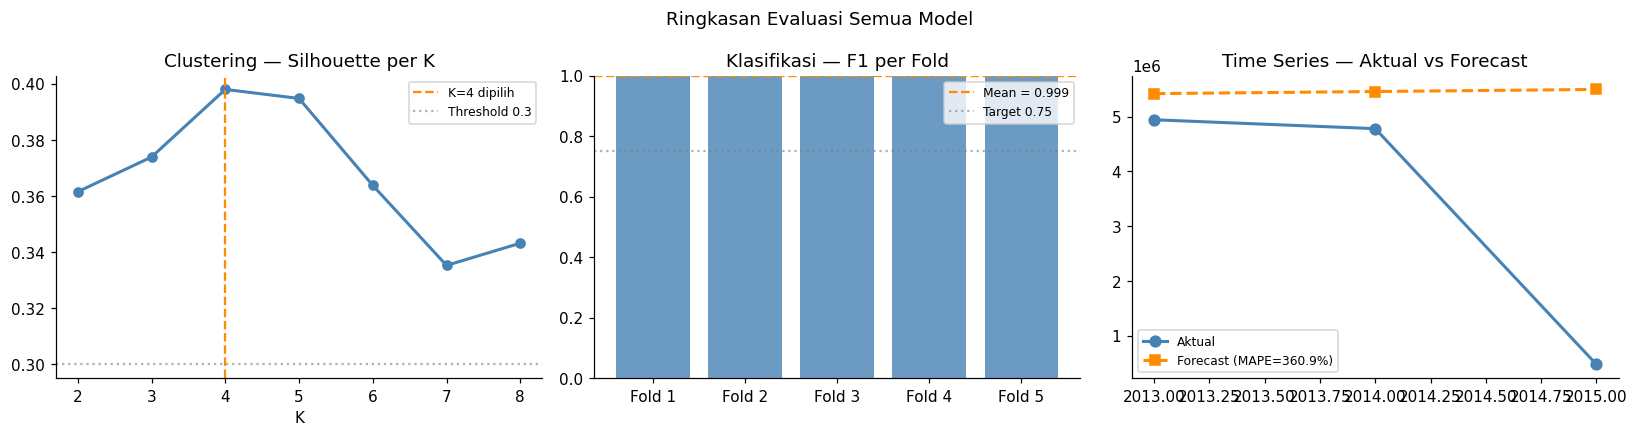

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Ringkasan Evaluasi Semua Model')

axes[0].plot(list(K_range), sil_scores, 'o-', color='steelblue', lw=2, ms=6)
axes[0].axvline(K_OPTIMAL, ls='--', color='darkorange', lw=1.5, label=f'K={K_OPTIMAL} dipilih')
axes[0].axhline(0.3, ls=':', color='gray', alpha=0.6, label='Threshold 0.3')
axes[0].set_title('Clustering — Silhouette per K')
axes[0].set_xlabel('K')
axes[0].legend(fontsize=8)

fold_labels = [f'Fold {i+1}' for i in range(5)]
axes[1].bar(fold_labels, cv_scores, color='steelblue', alpha=0.8)
axes[1].axhline(cv_scores.mean(), ls='--', color='darkorange', lw=1.5, label=f'Mean = {cv_scores.mean():.3f}')
axes[1].axhline(0.75, ls=':', color='gray', alpha=0.6, label='Target 0.75')
axes[1].set_title('Klasifikasi — F1 per Fold')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

axes[2].plot([2013, 2014, 2015], actual_test, 'o-', color='steelblue', lw=2, ms=7, label='Aktual')
axes[2].plot([2013, 2014, 2015], pred_test, 's--', color='darkorange', lw=2, ms=7, label=f'Forecast (MAPE={mape:.1f}%)')
axes[2].set_title('Time Series — Aktual vs Forecast')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fase5_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Fase 6 — Deployment

In [43]:
# Simpan model dan data hasil
joblib.dump(pipeline, 'model_classifier.pkl')
joblib.dump(km_final, 'model_kmeans.pkl')
joblib.dump(scaler,   'model_scaler.pkl')

df.to_csv('output_data_processed.csv', index=False)
df_cluster.to_csv('output_cluster_results.csv', index=False)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('output_forecast_2016_2018.csv', index=False)

print('Tersimpan: model_classifier.pkl, model_kmeans.pkl, model_scaler.pkl')
print('Tersimpan: output_data_processed.csv, output_cluster_results.csv')
print('Tersimpan: output_forecast_2016_2018.csv')

Tersimpan: model_classifier.pkl, model_kmeans.pkl, model_scaler.pkl
Tersimpan: output_data_processed.csv, output_cluster_results.csv
Tersimpan: output_forecast_2016_2018.csv


In [44]:
def predict_demand_level(area_ha, production_ton, yield_t_ha,
                          fert_rate, year, season, state):
    """
    Prediksi demand level pupuk untuk satu input baru.

    Parameters
    ----------
    area_ha       : float - luas lahan (hektar)
    production_ton: float - hasil produksi (ton)
    yield_t_ha    : float - yield (ton/ha)
    fert_rate     : float - dosis pupuk (kg N/ha)
    year          : int   - tahun tanam
    season        : str   - musim ('Kharif', 'Rabi', dll)
    state         : str   - nama negara bagian

    Returns
    -------
    str: 'Low', 'Medium', atau 'High'
    """
    input_df = pd.DataFrame([{
        'area'           : area_ha,
        'production'     : production_ton,
        'yield_per_ha'   : yield_t_ha,
        'fert_rate_kg_ha': fert_rate,
        'crop_year'      : year,
        'season'         : season,
        'state_name'     : state,
    }])
    return pipeline.predict(input_df)[0]


hasil = predict_demand_level(
    area_ha=500, production_ton=1800, yield_t_ha=3.6,
    fert_rate=120, year=2015, season='Kharif', state='Punjab'
)
print(f'Input  : Punjab, Kharif, 500 ha, Rice')
print(f'Output : Demand Level = {hasil}')

Input  : Punjab, Kharif, 500 ha, Rice
Output : Demand Level = Medium


In [46]:
# Download semua output
from google.colab import files

output_files = (
    glob.glob('fase*.png') +
    glob.glob('output_*.csv') +
    glob.glob('*.pkl') +
    ['fase4_peta_distribusi.html']
)

for f in output_files:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>